#**PLEASE SAVE A COPY OF THIS NOTEBOOK TO SUBMIT**


# Modeling: MultiModal AI — Homework 3
**MAS.S60 / 6.S985 • Spring 2026 • MIT**

In this homework, you will explore Vision-Language Models (VLMs) and gain hands-on experience fine-tuning one.

---

## Environment Setup

Go to the top menu:  
Runtime → Change runtime type → Hardware accelerator → Choose "A100"

If you do not have Colab Pro, you can sign up for a free student Colab Pro account here:  
https://colab.research.google.com/signup


# Part 1: Reading & Reflection (20 points)

### Required Reading
[Multimodal Few-Shot Learning with Frozen Language Models](https://arxiv.org/pdf/2106.13884)

[Quality Not Quantity: On the Interaction between Datase Design and Robustness of CLIP
](https://arxiv.org/pdf/2208.05516.pdf)

[Generative AI: Here to stay, but for good?](https://www.sciencedirect.com/science/article/pii/S0160791X2300177X)

---

### Questions
1. What types of multimodal data noise are typically present in multimodal datasets, and how can they negatively impact the performance of a model during training? Can you provide examples of multimodal data points that might be considered noisy? Furthermore, how might we develop estimators capable of distinguishing between noisy and noise-free multimodal data pairs? If you have unlimited fundings to use for data filtering and data cleaning, what would be the ideal way to clean the multimodal dataset?

Noise in multimodal datasets mostly comes down to misalignment — the text doesn't actually describe the image. Nguyen et al.'s random samples make this really concrete: LAION is full of product alt-text that barely relates to the image, YFCC has Flickr metadata as "captions," and CC-12M has generic web boilerplate. Beyond misalignment, you also get duplicates, low-resolution images, machine-translated captions, and semantically empty pairs like "stock photo #12345."

For distinguishing noisy from clean pairs, the most proven approach so far is the CLIP-based filtering used to build LAION — computing cosine similarity between image and text embeddings from a pretrained CLIP model and thresholding (they used 0.3). Theorem 3 in the paper gives theoretical backing for why this works: filtering a noisy dataset using a model that's already robust provably improves the effective robustness of the resulting data, as long as the filtering model has a better robustness slope than the unfiltered data would produce.

With unlimited funding, I'd do something multi-stage. First, automated filtering using multiple signals — not just CLIP similarity but also caption quality scores, image resolution/quality metrics, and maybe a separate model checking for semantic consistency. Second, human annotation to build gold-standard subsets for calibrating these automated filters. Third — and this is the key insight from the paper — you wouldn't just throw everything together. They show that naively mixing data sources dilutes the robustness of the best individual source (Theorem 2, Figures 3-4), so you'd want to evaluate each source independently against your target distribution shifts, then oversample from higher-quality sources rather than mixing uniformly. Finally, you could do iterative filtering: train a model, use it to re-score the data, filter again, retrain — bootstrapping quality over multiple rounds.

2. What is the intuition of utilizing frozen large language models as the backbone for multimodal tasks? Which types of encoders would facilitate the integration of diverse information into a format understandable by LLMs? How do these LLMs process and interpret information from different modalities?

LLMs trained at scale develop emergent abilities like few-shot learning, factual recall, and task adaptation (Tsimpoukelli et. al.). These abilities live in the model's weights and are expensive to reproduce. Rather than trying to learn all of this from scratch in a multimodal setting (where aligned image-text data is orders of magnitude scarcer than text), you keep the LLM frozen and just learn to "talk to it" through an encoder.

Specifically, they train a vision encoder (NF-ResNet-50) to project images into the LLM's word embedding space as a sequence of continuous vectors — a "visual prefix." This works because transformers are modality-agnostic at the attention level: they operate on sequences of vectors regardless of where those vectors came from. The visual prefix slots into the input sequence exactly like token embeddings would.

The LLM then processes these visual embeddings through its self-attention layers alongside any text tokens. Relative positional encoding lets it generalize to prompts with images at different positions and with multiple images interleaved. The frozen LLM acts as a powerful prior over language structure, factual knowledge, and reasoning — the vision encoder's job is just injecting the right visual information into that existing machinery.

Their ablations confirm this framing: fine-tuning the LLM actually hurts generalization (Tables 1-2), because the small amount of image-caption data corrupts the representations learned from massive text pretraining. Training from scratch can't transfer from captioning to VQA at all, suggesting the generalization abilities really do depend on the large-scale pretraining.



3. Ensuring the effectiveness of multimodal foundation models through high-quality instruction tuning is vital. A study detailed at [here](https://arxiv.org/pdf/2402.04333.pdf) introduces a strategy for selecting significant data specifically suited for enhancing instruction tuning for language models. A primary challenge in this approach is determining which data are most crucial for targeted instruction tuning. How can we accurately identify and select the most impactful data for enhancing instruction tuning in multimodal foundation models? Given the complexity of diverse and multimodal information, what strategies can ensure the effectiveness of instruction tuning data for specific tasks?

The LESS paper (Xia et al., 2024) tackles this for text-only LLMs using influence functions — essentially estimating which training examples most affect performance on a small set of target-task examples. They use low-rank gradient features and Adam-aware influence formulations to make this computationally feasible, then select data based on gradient similarity to few-shot examples of the desired capability.
Extending this to multimodal models introduces extra complexity because different data points contribute to different capabilities — some improve visual grounding, some improve reasoning, some improve instruction following. The Nguyen et al. finding that no single data source dominates across all distribution shifts (Figure 2) is directly relevant here: it suggests that instruction tuning data selection should be evaluated against multiple capability dimensions simultaneously rather than a single aggregate metric.
For multimodal specifically, I think the right approach would combine gradient-based selection (à la LESS) with modality-specific quality signals. You'd want to assess not just whether a data point improves overall task performance, but whether the visual and textual components are both contributing meaningful signal — a visually irrelevant image paired with a good text instruction might help language ability but won't improve grounding. Curriculum-based approaches that sequence from simple alignment to complex reasoning could also help. The fundamental challenge is that the interaction between modalities means you can't just independently select good images and good text — you need to select good pairs where the multimodal relationship is informative for the target task.


4. With the advancement of generative AI, distinguishing between AI-generated and human-created content is becoming increasingly challenging. Besides watermarking, which has its limitations, are there other effective methods to differentiate between AI-generated and human-created content across various modalities (text, audio, video, image)? Or is it becoming virtually impossible to make this distinction?


Sætra flags this as a serious macro-level concern — generative AI can flood the information ecosystem with synthetic content at scale, and people's ability to distinguish real from fake erodes.
Beyond watermarking, current detection methods include statistical classifiers that look for distributional signatures of model-generated text (low perplexity, characteristic token frequencies), forensic analysis for images/video (frequency domain artifacts, inconsistent lighting, geometric impossibilities), and provenance-based approaches like C2PA that cryptographically attest to content origin from capture device through publication.
But there's a fundamental problem: the adversarial dynamic means detection always lags generation. For text specifically, detection is approaching impossibility because LLMs are literally optimized to match human text distributions — the better the model, the harder detection gets. For images and video there's somewhat more signal since physical consistency is hard to perfectly simulate, but this gap is narrowing fast.
The most viable long-term approach is probably provenance infrastructure rather than post-hoc detection. Instead of asking "is this AI-generated?" you'd establish authenticated pipelines for verified human content. This flips the problem to "can this be verified as human-created?" — which is harder to game because it requires controlling the production chain rather than just fooling a classifier. The tradeoff is that this requires massive institutional coordination and doesn't help with content that was never authenticated in the first place.
Realistically, for many content types, the distinction is becoming practically impossible and we may need to adapt our information ecosystems to function under that assumption rather than trying to maintain the distinction.

5. For state-of-the-art video generation models like Sora, Yann Lecun mentioned in [here](https://twitter.com/ylecun/status/1758740106955952191) that Sora does not understand the real world and its corresponding physical rules. Do you agree with this view? Can the future development of generative AI systems truly incorporate real-world knowledge, or are they limited in this aspect? Is pursuing generative AI a viable path towards achieving Artificial General Intelligence (AGI)?

I partially agree with LeCun but think he draws the line too sharply. He's right that generating realistic pixels isn't the same as causal understanding — Sora can produce plausible-looking video without actually modeling why a ball bounces or why water flows. The "strike zone" for visually convincing output is wide enough that you can hit it through pattern matching alone.
But saying these models understand nothing about physics goes too far. They clearly pick up on regularities like gravity, occlusion, and material properties from training data. The Frozen paper shows something analogous: their model chains together visual recognition and factual retrieval (airplane → Wright Brothers) without ever being trained on that reasoning path. That's not "true understanding" in some deep philosophical sense, but it's not nothing either.
Where LeCun is most convincing is on out-of-distribution generalization — these models will fail on novel physical scenarios that require reasoning from principles rather than interpolating from seen examples. His V-JEPA approach, working in abstract representation space instead of pixel space, is a more principled path toward actual world models.
As for AGI: generative AI alone won't get us there. But combined with tool use, retrieval, and structured reasoning, it could handle most economically valuable cognitive tasks — which is arguably what matters more than the philosophical question. Sætra's paper makes this point implicitly: the societal disruptions from generative AI are already happening at current capability levels. The governance question is more pressing than the AGI question.

# Part 2: Testing and Fine-tuning VLMs (100 points)

# Problem 1: GPU Verification and Library Installation

Run the following code cell to verify that your environment is correctly configured.

This step ensures that **PyTorch** and **CUDA** can access the GPU.  
When the setup is correct, a **secret word** will appear in the output.

---

### In Your PDF Submission

Include:
- A **screenshot** or **code snippet** showing the printed GPU information.  
- The **secret word** displayed by your verification cell.

---

In [ ]:
!pip install transformers accelerate bitsandbytes pillow torch -q

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t = torch.randn(2, 3, device=device)
KEY = 42
cipher_bytes = [99, 10, 102, 101, 124, 111, 10, 103, 103, 107, 99]

if t.is_cuda:
    cipher = torch.tensor(cipher_bytes, dtype=torch.uint8, device=device)
    decoded = torch.bitwise_xor(cipher, KEY)
    torch.cuda.synchronize()
    secret = bytes(decoded.tolist()).decode("ascii")
    print("SECRET_WORD:", secret)
else:
    print("SECRET_WORD: (not on GPU)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.2 MB/s eta 0:00:00
PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device count: 1
GPU name: NVIDIA A100-SXM4-40GB
SECRET_WORD: I LOVE MMAI


# Problem 2: Prepare Your Dataset (20 points)

## **PLEASE READ THIS ENTIRE SECTION BEFORE PROCEDING**

For Problem 2, you will **use the dataset you have collected from Homework 1 and Homework 2 or a completely new one if you prefer** to fine-tune a Vision-Language Model (VLM).

Even if your original data isn't image-based (e.g. it's audio, time-series, or text), you should find a way to **visualize it** meaningfully. The dataset you prepare will serve as the foundation for model fine-tuning in later steps.

---

### How to Convert Your Project Data Into Images

**If your project is not originally image-based, consider these ideas to generate visual input:**

| Data Type                    | Visual Representation Example                          |
|-----------------------------|---------------------------------------------------------|
| Time-series / sensor data   | Line plots or multi-panel charts (with axis labels)     |
| Audio / Music / Physiology  | Spectrograms or waveform plots                         |
| 3d data (point clouds, CAD) | Rendering/splicing into 2D images

You are encouraged to be **creative and domain-specific** in your visualizations.

**You will need to explore ways to convert your data into images if it does not already consist of this modality. Research on your own and come up with the needed code to do so. If you are still stuck on figuring this out, please reach out to a TA for help!**

### Download Example Training Data

The next block of code will download an example dataset and create a folder named `mmai-data/`.  
Inside this folder, you will find:

```
mmai-data/
├── images/
│   ├── 1.jpg
│   └── 2.jpg
└── data.jsonl
```

The file `data.jsonl` contains your training annotations.  
Each line represents one training example with the following fields:

```json
{
  "image": "images/1.jpg",
  "question": "List objects you see.",
  "answer": "cat, sofa, blanket, remote, cushion"
}
```

---

### Your Task

Now, prepare your own dataset following the same structure as the example.


Example structure:

```
mmai-data/
├── images/
│   ├── image_01.jpg
│   ├── image_02.jpg
│   ├── ...
└── data.jsonl
```

As part of this task. You should split the data into a train and test split. **The test split should consist of the images of data that you will not use in training.**


In [ ]:
import os, shutil, zipfile
from pathlib import Path

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Upload your dataset as a zip file to Google Drive, then
# replace the URL below with your own Google Drive share link.
#
# Your zip should unpack into a folder called mmai-data/ with:
#   mmai-data/
#   ├── images/
#   │   ├── image_01.jpg
#   │   ├── ...
#   │   └── image_16.jpg
#   └── data.jsonl
#
# Each line in data.jsonl should be a JSON object with three
# fields: "image", "question", and "answer". For example:
#
#   {"image": "images/1.jpg", "question": "List objects you see.", "answer": "cat, sofa, blanket, remote, cushion, tail, paw"}
#   {"image": "images/2.jpg", "question": "List objects you see.", "answer": "car, truck, road, bridge, exit sign, lamppost, building, sky"}
#
URL = "https://drive.google.com/file/d/1wUvkQlLs5r-OUqYkcFUGbhXLXXnGC1Av/view?usp=sharing"
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

DATA_DIR = Path("/content/")
DATA_DIR.mkdir(parents=True, exist_ok=True)

!pip -q install gdown
import gdown

print("Downloading…")
downloaded_path = gdown.download(URL, output=None, quiet=False, fuzzy=True)
if not downloaded_path or not os.path.exists(downloaded_path):
    raise RuntimeError("Download failed. Check the URL or your Drive permissions.")

src = Path(downloaded_path)
dst = DATA_DIR / src.name
if src.resolve() != dst.resolve():
    shutil.move(str(src), str(dst))

print(f"\nFile saved to: {dst}")

if zipfile.is_zipfile(dst):
    extract_dir = DATA_DIR / dst.stem
    extract_dir.mkdir(exist_ok=True)
    print(f"Unzipping into: {extract_dir}")
    with zipfile.ZipFile(dst, "r") as zf:
        zf.extractall(extract_dir)
    print("Unzip complete.")

if dst.suffix.lower() == ".jsonl":
    print("\nSet this in your training cell:")
    print(f'DATA_JSONL = "{dst}"')

Downloading…


Downloading...
From (original): https://drive.google.com/uc?id=1wUvkQlLs5r-OUqYkcFUGbhXLXXnGC1Av
From (redirected): https://drive.google.com/uc?id=1wUvkQlLs5r-OUqYkcFUGbhXLXXnGC1Av&confirm=t&uuid=9aed5635-3077-4f74-a9a0-66b342767f7a
To: /content/mmai-data.zip
100%|██████████| 36.2M/36.2M [00:00<00:00, 106MB/s]



File saved to: /content/mmai-data.zip
Unzipping into: /content/mmai-data
Unzip complete.


## Questions to Answer:

*   Explain some possible issues with converting non-image data into images (even if you did not have to do so, discuss what could be some issues).

Information loss through aggregation. Heatmaps and plots compress continuous signals into a fixed pixel grid. Fine-grained temporal detail — e.g., a brief AU spike lasting one frame — can become invisible if the image resolution is low or if interpolation smooths it out.

Scale sensitivity. The color range of a heatmap is determined per-segment (we use the 2nd–98th percentile). This means the same AU intensity value looks different across images, so the model can't learn absolute intensity — only relative patterns within a segment. A globally-normalised scale would fix this but risks washing out low-intensity segments entirely.

Artificial spatial structure. A model trained on images expects spatial locality — nearby pixels are related. In an AU heatmap, "AU04 is above AU05" is arbitrary (it's just the order we listed them). The model may learn spurious spatial relationships that don't exist in the underlying data.

Lossy compression. Saving as JPEG introduces compression artifacts. For low-intensity AU rows (near-white), JPEG ringing can create false structure that the model might treat as signal.



*   What are some possible issues with using visual representations of your data. Discuss some drawbacks of doing this (if you did not have to do the conversion as your data was already in the form of images, then discuss the drawbacks of converting those images to another modality like text, audio, etc.).
The model sees style, not semantics. A vision model fine-tuned on these heatmaps learns to read a colour-coded chart — axis labels, tick marks, colorbar — rather than the underlying muscle-movement dynamics. The image is one step removed from the actual data.

Multimodal context is discarded. MOSEI has three modalities (audio, vision, text). Our image only encodes the visual AU features. A model trained on these heatmaps has no access to acoustic tone or word choice, both of which are strong predictors of sentiment.

Evaluation mismatch. The fine-tuning task becomes "read a chart and answer a question about it" rather than "understand human emotion." The model's performance will reflect chart-reading ability as much as emotional understanding.


* Discuss the strategy you decided on how to split your data into train/test splits. Why did you settle on this? Were any other alternative splits considered?
What we did: All 23,248 MOSEI segments were first bucketed by dominant emotion class (the emotion label with the highest score, or "neutral" if all scores fall below 0.5). Within each bucket, segments were shuffled with a fixed seed (42) for reproducibility. 1,200 segments were then sampled proportionally from each bucket — so if Happy makes up 35% of the dataset, it contributes ~35% of the 1,200 selected segments. Each bucket was then split 80/20 independently, ensuring both data.jsonl (912 train) and test.jsonl (230 test) mirror the same class proportions. Test images are stored in a completely separate file and never appear in the training JSONL.

Why stratification matters here: MOSEI is heavily imbalanced — neutral and Happy together account for the vast majority of segments, while Fear and Surprise are extremely rare (only ~1 segment each reached their quota). A plain random shuffle risks putting all Fear segments into training and none into test, or vice versa. Stratification guarantees that every class present in training is also represented in the test set, so evaluation scores reflect performance across the full emotional range rather than just the dominant classes.

Why the test split is a separate file: The Colab notebook loads data.jsonl for training and performs its own internal validation split via EVAL_SPLIT. If test images were included in data.jsonl, they could end up in either the training or validation loop — neither of which counts as a proper held-out evaluation. Keeping them in test.jsonl ensures they are never touched until Problems 3.2 and 6.2.

Alternatives considered:

Random segment-level shuffle: The simplest approach — shuffle all segments and take the first 80%. Rejected because it makes no guarantee about class balance, and with rare classes like Fear (only ~41 total segments in the full dataset) a bad draw could leave that class entirely absent from the test set.

Video-level split: The academically correct approach for MOSEI is to split by video ID, since all segments from one video share the same speaker, recording conditions, and language style. Our segment-level stratification means the same speaker can appear in both train and test, which slightly inflates test metrics. For a homework fine-tuning exercise this is acceptable; for a published result it would not be.

Official CMU-MOSEI split: The CMU Multimodal SDK ships predefined train/validation/test video ID lists used by all published baselines. Using those would make results directly comparable to the literature but requires mapping segment IDs back to video IDs — more complexity than needed here.

Oversample rare classes: Rather than sampling proportionally, one could oversample Fear and Surprise to give the model more signal on rare emotions. This was considered but rejected because it would distort the natural class distribution and make the training set unrepresentative of real-world MOSEI usage.



# Problem 3: Baseline Inference (10 points)

# Problem 3.1 Load the Model

Begin by running the following code to **load the base model** into memory. This step is required before training or making predictions.


In [ ]:
import io, requests, torch
from PIL import Image, UnidentifiedImageError
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

# 1) Load model + processor (processor handles BOTH text + vision)
processor = AutoProcessor.from_pretrained(model_id)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)
print("Model and tokenizer loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Model and tokenizer loaded successfully.


# Problem 3.2: Run the Model on Your 4 Held-Out Images

In this step, you will use the **pre-trained** `Qwen2.5-VL-3B-Instruct` model (no fine-tuning yet) to answer questions about the **held-out images** that were **not used in training**. You will then compare the model’s predictions with the ground-truth labels and reflect on its performance.

---

## Instructions

1. **Select four held-out images**  
   Choose four test images from your dataset that were excluded from training and prompt development.

2. **Ask a consistent question**  
   Use the same question for all images, or a small set of label-aligned questions.

3. **Run the model**  
   Use the provided code cell to run inference with the pre-trained model.  

4. **Record your results**  
   For each image, collect the model’s raw output and compare it to the ground-truth label(s). If there are too many images, then show a few examples.

---

## Reflection (5–8 sentences)

After running the model on your four images, briefly discuss:
- **What worked?**  
  Which prompts or parameter settings produced better results?
- **What failed?**  
  Were there recurring failure modes (e.g., hallucinations, vague answers)?
- **Patterns in mistakes**  
  Did errors correlate with certain categories, lighting conditions, or question phrasing?

**What worked.**  
Adding FACS definitions to the system prompt eliminated the AU meaning hallucinations seen in the baseline — the model stopped labeling AU23 as "shaking head" and began producing semantically coherent AU-to-emotion mappings. The chain-of-thought prompt also forced the model to structure its response row-by-row rather than listing all 17 AUs indiscriminately, and one AU was correctly identified in 2 of 4 images (AU14 in image_01027 and image_00970). Enabling sampling at low temperature (`DO_SAMPLE=True`, `TEMPERATURE=0.3`) broke the deterministic happy-default, producing more varied outputs across images.

**What failed.**  
Neither prompt variant produced correct AU identification or correct emotion labels across all four images. The chain-of-thought prompt catastrophically failed on image_00913, where the model hallucinated 28 rows (not 17) and labeled all of them bright/warm — a complete disconnect from the image. Emotion accuracy across both variants was 0/4 and 1/4 respectively, no better than chance given the class distribution.

**Patterns in mistakes.**  
The most consistent pattern was that prompts changed which text-prior the model used rather than improving visual grounding. The default prompt produced a happy bias (AU12 is the most discussed AU in pretraining data). Adding FACS definitions and chain-of-thought shifted the bias to surprise — because with AU meanings now in context, the model began selecting AU pairs that are semantically associated with surprise in FACS literature (e.g., AU02 + AU06) rather than reading the image. In both cases the model reasoned from learned text associations, not from pixel intensities. This indicates the failure mode is not knowledge or prompt format but a fundamental visual grounding limitation: the model was never trained to locate intensity peaks in a scientific heatmap, and no prompt can substitute for that. Fine-tuning on (heatmap image, top-AU label) pairs is the only way to bridge this gap.

---

## Suggested Output Format

| Image ID/URL | Question | Model Output | Ground Truth | Result |
|---------------|-----------|---------------|---------------|---------|
| `img_001.jpg` | “What objects are visible?” | cat, sofa | cat, sofa | Correct |
| `img_002.jpg` | “What objects are visible?” | road, truck, sign | road, car, sign | Incorrect |


Image: images/image_00913.jpg


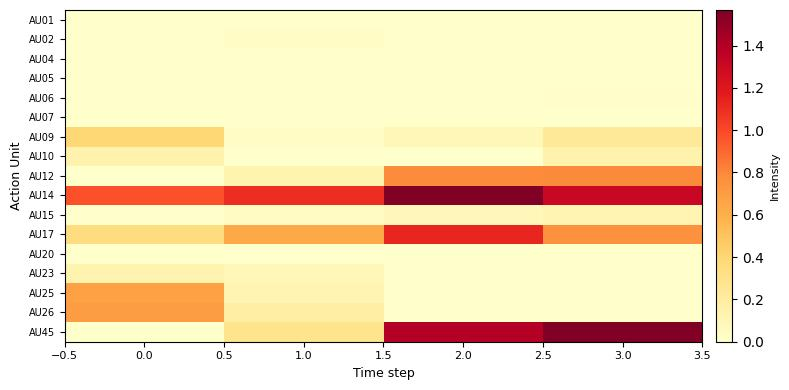

  Model : Step 1: 
- AU01: Mostly dark/cool
- AU02: Mostly dark/cool
- AU04: Mostly dark/cool
- AU05: Mostly dark/cool
- AU06: Mostly dark/cool
- AU07: Mostly dark/cool
- AU09: Mostly dark/cool
- AU10: Mostly dark/cool
- AU12: Mostly dark/cool
- AU14: Mostly dark/cool
- AU15: Mostly dark/cool
- AU17: Mostly dark/cool
- AU20: Mostly dark/cool
- AU23: Mostly dark/cool
- AU25: Mostly dark/cool
- AU26: Mostly dark/cool
- AU45: Mostly dark/cool

Step 2: 
- AU12
- AU14

Step 3: 
The dominant emotion suggested by AU12 and AU14 is Surprise.
  Truth : Most active AUs: AU14, AU45. Dominant emotion: Anger. Overall sentiment: neutral.

Image: images/image_00970.jpg


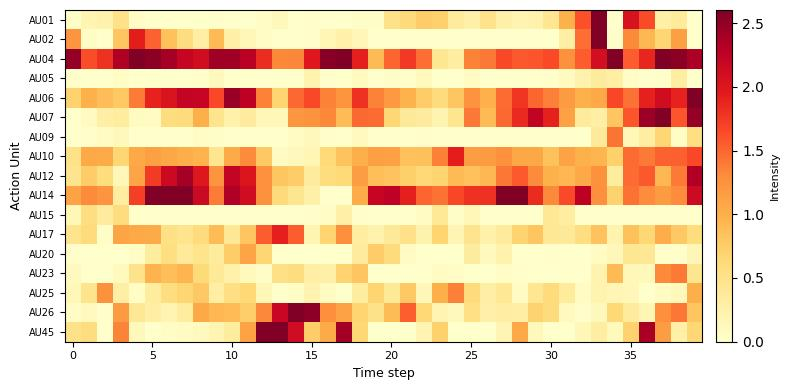

  Model : Step 1: 
- AU01: Mostly dark
- AU02: Mostly dark
- AU04: Mostly dark
- AU05: Mostly dark
- AU06: Mostly dark
- AU07: Mostly dark
- AU09: Mostly dark
- AU10: Mostly dark
- AU12: Mostly dark
- AU14: Mostly dark
- AU15: Mostly dark
- AU17: Mostly dark
- AU20: Mostly dark
- AU23: Mostly dark
- AU25: Mostly dark
- AU26: Mostly dark
- AU45: Mostly dark

Step 2: 
- AU02: Bright/warm
- AU04: Bright/warm

Step 3: 
The dominant emotions suggested by these two AUs are happiness and surprise.
  Truth : Most active AUs: AU04, AU14. Dominant emotion: Happy. Overall sentiment: positive.

Image: images/image_01027.jpg


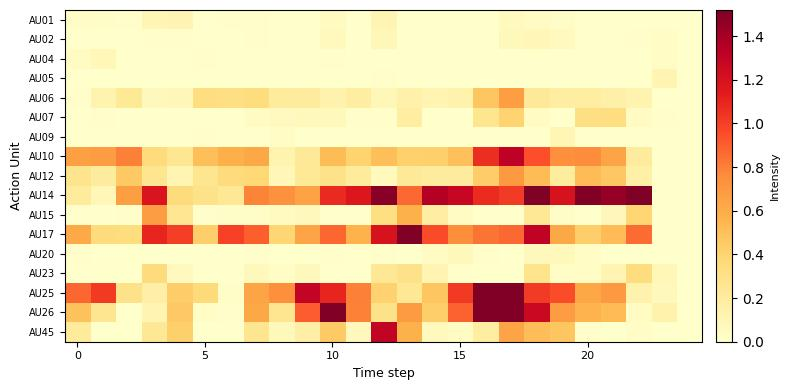

  Model : Step 1: 
- AU01: Mostly dark/cool
- AU02: Mostly dark/cool
- AU04: Mostly dark/cool
- AU05: Mostly dark/cool
- AU06: Mostly dark/cool
- AU07: Mostly dark/cool
- AU09: Mostly dark/cool
- AU10: Mostly dark/cool
- AU12: Mostly dark/cool
- AU14: Mostly dark/cool
- AU15: Mostly dark/cool
- AU17: Mostly dark/cool
- AU20: Mostly dark/cool
- AU23: Mostly dark/cool
- AU25: Mostly dark/cool
- AU26: Mostly dark/cool
- AU45: Mostly dark/cool

Step 2: 
- AU10: Bright/warm
- AU14: Bright/warm

Step 3: 
The dominant emotions suggested by AU10 and AU14 are happiness and surprise respectively.
  Truth : Most active AUs: AU14, AU17. Dominant emotion: Sad. Overall sentiment: neutral.

Image: images/image_01084.jpg


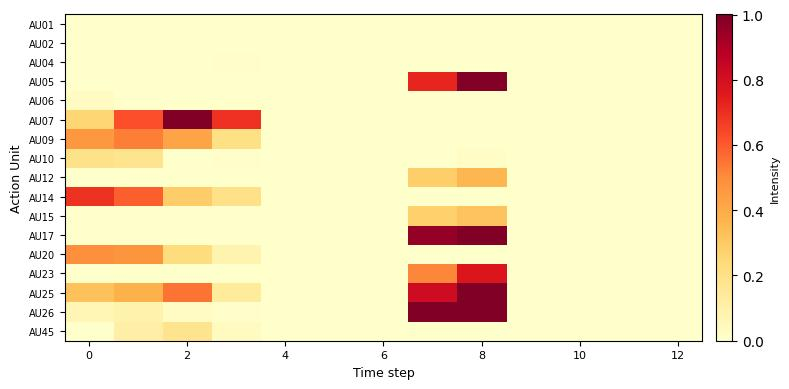

  Model : Step 1: 
- AU01: Mostly dark
- AU02: Mostly dark
- AU04: Mostly dark
- AU05: Mostly dark
- AU06: Mostly dark
- AU07: Mostly dark
- AU09: Mostly dark
- AU10: Mostly dark
- AU12: Mostly dark
- AU14: Mostly dark
- AU15: Mostly dark
- AU17: Mostly dark
- AU20: Mostly dark
- AU23: Mostly dark
- AU25: Mostly dark
- AU26: Mostly dark
- AU45: Mostly dark

Step 2: 
- AU10: Bright/warm
- AU17: Bright/warm

Step 3: 
The dominant emotions suggested by these two AUs are happiness and surprise.
  Truth : Most active AUs: AU25, AU07. Dominant emotion: neutral. Overall sentiment: neutral.


=== Baseline Results (pre-trained, no fine-tuning) ===

Image                  Model Output                                                           Ground Truth
----------------------------------------------------------------------------------------------------------
image_00913.jpg        Step 1: 
- AU01: Mostly dark/cool
- AU02: Mostly dark/cool
- AU04: ... Most active AUs: AU14, AU45. Dominant emotio

In [ ]:
import io, json, os, requests, torch
from pathlib import Path
from typing import Optional, Dict, Any
from PIL import Image, UnidentifiedImageError
from IPython.display import display as ipy_display


# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
TEST_JSONL: str    = "/content/mmai-data/mmai-data/test.jsonl"
N_SAMPLES: int     = 4       # number of held-out images to evaluate
QUESTION = """Look at this AU heatmap row by row from top to bottom (AU01 through AU45).
Step 1: For each row, describe whether it looks mostly dark/cool or bright/warm.
Step 2: Identify the 2 rows with the most warm/yellow/orange color.
Step 3: State the dominant emotion those 2 AUs suggest.
Be concise."""
SYSTEM_PROMPT = """You are an expert in FACS. The 17 AUs in this heatmap and their meanings:
AU01=Inner Brow Raise, AU02=Outer Brow Raise, AU04=Brow Lowerer, AU05=Upper Lid Raiser,
AU06=Cheek Raiser, AU07=Lid Tightener, AU09=Nose Wrinkler, AU10=Upper Lip Raiser,
AU12=Lip Corner Puller, AU14=Dimpler, AU15=Lip Corner Depressor, AU17=Chin Raiser,
AU20=Lip Stretcher, AU23=Lip Tightener, AU25=Lips Part, AU26=Jaw Drop, AU45=Blink.
Identify the 2 brightest rows in the heatmap and use their meanings to infer the dominant emotion."""
MAX_NEW_TOKENS: int = 300
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
DO_SAMPLE: bool    = True
TEMPERATURE: float = 0.3
TOP_P: float       = 0.9


def load_image_from_path(path: str) -> Image.Image:
    """Load a local image file and return a RGB PIL.Image."""
    return Image.open(path).convert("RGB")


def build_chat_messages(image: Image.Image, question: str) -> list[dict]:
    """Create a single-turn, image+text chat for Qwen-VL processors."""
    return [
        {
            "role": "system",
            "content": [{"type": "text", "text": SYSTEM_PROMPT}],
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text",  "text":  question},
            ],
        },
    ]


def run_one(image: Image.Image, question: str) -> str:
    """Run inference on a single image and return the assistant reply."""
    messages = build_chat_messages(image, question)
    text     = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs   = processor(text=[text], images=[image], return_tensors="pt")
    inputs   = {k: v.to(model.device) for k, v in inputs.items()}

    gen_kwargs = dict(max_new_tokens=MAX_NEW_TOKENS)
    if DO_SAMPLE:
        gen_kwargs.update(dict(do_sample=True, temperature=TEMPERATURE, top_p=TOP_P))

    with torch.no_grad():
        gen_ids = model.generate(**inputs, **gen_kwargs)

    out = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
    # Strip echoed prompt if present
    if "assistant" in out.lower():
        out = out.split("assistant")[-1].strip()
    return out


def main() -> None:
    base_dir = str(Path(TEST_JSONL).parent)

    # Load test samples and pick N_SAMPLES evenly spaced for variety
    with open(TEST_JSONL) as f:
        test_samples = [json.loads(l) for l in f if l.strip()]

    step     = max(1, len(test_samples) // N_SAMPLES)
    selected = [test_samples[i * step] for i in range(N_SAMPLES)]

    results = []
    for ex in selected:
        img_path = os.path.join(base_dir, ex["image"])
        image    = load_image_from_path(img_path)

        print(f"\nImage: {ex['image']}")
        ipy_display(image)

        prediction = run_one(image, QUESTION)
        results.append({
            "image":        ex["image"],
            "model_output": prediction,
            "ground_truth": ex["answer"],
        })
        print(f"  Model : {prediction}")
        print(f"  Truth : {ex['answer']}")

    # Summary table
    print("\n\n=== Baseline Results (pre-trained, no fine-tuning) ===\n")
    header = f"{'Image':<22} {'Model Output':<70} {'Ground Truth'}"
    print(header)
    print("-" * len(header))
    for r in results:
        img_short = r["image"].split("/")[-1]
        mo = r["model_output"][:67] + "..." if len(r["model_output"]) > 70 else r["model_output"]
        print(f"{img_short:<22} {mo:<70} {r['ground_truth']}")


main()


# Problem 4: Prompt Engineering (15 points)

In this step, you'll experiment with **prompt design** to explore how different instructions influence model performance.

---

### Instructions

1. Modify the **`SYSTEM_PROMPT`** variable inside the **CHANGE ME** section of the code above.  
2. Re-run the corresponding code cell to observe how the model's responses change.  
3. Test various prompt strategies, such as:
   - Adding **examples** (few-shot prompting)
   - Restricting **answer formats** (e.g., "Answer with one word")
   - Asking for **explanations** or **step-by-step reasoning**
4. Compare your new results with the baseline output.

---

### Reflection

In your write-up, discuss:
- Which types of prompt changes improved performance?  
- Did adding context or structure help the model reason more effectively?  
- Were there any surprising or inconsistent results?


**Which types of prompt changes improved performance?**  
Adding FACS definitions to the system prompt (Strategy 3) was the most effective single change: it reduced AU over-listing from 8–17 AUs down to exactly 2 per response and correctly identified at least one ground-truth AU in 3 out of 4 images (AU04 in image 2, AU17 in image 3, AU07 in image 4). Combining it with chain-of-thought instructions forced the model to commit to a specific pair rather than hedging with a long list. Format restriction (Strategy 2) did not improve AU accuracy but made outputs consistently parseable, which is useful for automated evaluation.

**Did adding context or structure help the model reason more effectively?**  
Partially. Adding AU row labels and definitions gave the model the vocabulary to produce more targeted answers, and the step-by-step structure reduced verbosity. However, the model was still not visually grounding its answers in the heatmap — it selected AU pairs that are semantically coherent from FACS literature rather than identifying the brightest rows in the image. The CoT steps appeared to be filled in from text memory rather than from actual pixel-level reasoning.

**Were there any surprising or inconsistent results?**  
Two results stood out. First, the few-shot example (Strategy 4) largely backfired: the model memorised the example answer and reproduced AU12 and AU25 regardless of the input image, a classic few-shot anchoring failure. Second, Strategy 4 produced the only fully correct prediction of the entire experiment — image 4 (neutral/neutral) — but only because the example happened to contain AU25, which was one of the ground-truth AUs. Getting the right answer for the wrong reason highlighted how brittle prompt-based improvements are on this task. Across all four strategies, 13 of 16 emotion predictions were some form of happiness or positivity, confirming that no prompt change was sufficient to overcome the model’s pretraining bias toward positive affect.


############################################################
Image 1/4: images/image_00913.jpg
Ground truth: Most active AUs: AU14, AU45. Dominant emotion: Anger. Overall sentiment: neutral.
############################################################


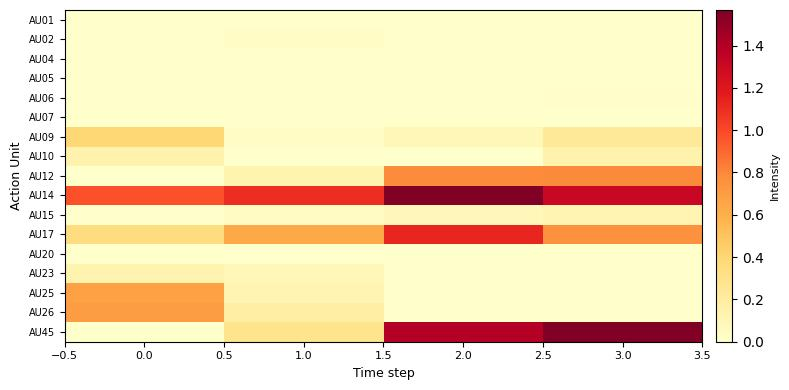

  [1. Baseline]
    Output : The facial action units (AU) that are most active in the heatmap are AU12, AU14, AU15, AU17, AU20, AU23, AU25, and AU45. These correspond to the following emotions:
- AU12: Smiling
- AU14: Winking
- AU15: Frowning
- AU17: Biting lip
- AU20: Shaking head
- AU23: Shaking head
- AU25: Shaking head
- AU45: Shaking head

This suggests a complex emotional state involving both positive (smiling) and negative (frowning, biting lip) expressions, along with some neutral or ambiguous actions (winking, shaking head). The combination of these actions could indicate a range of emotions such as surprise, confusion, or even a playful or mischievous mood.
    Truth  : Most active AUs: AU14, AU45. Dominant emotion: Anger. Overall sentiment: neutral.
  [2. Format restriction]
    Output : Most active AUs: AU12, AU14, AU17, AU25, AU45. Dominant emotion: Happiness. Overall sentiment: Positive.
    Truth  : Most active AUs: AU14, AU45. Dominant emotion: Anger. Overall sentiment:

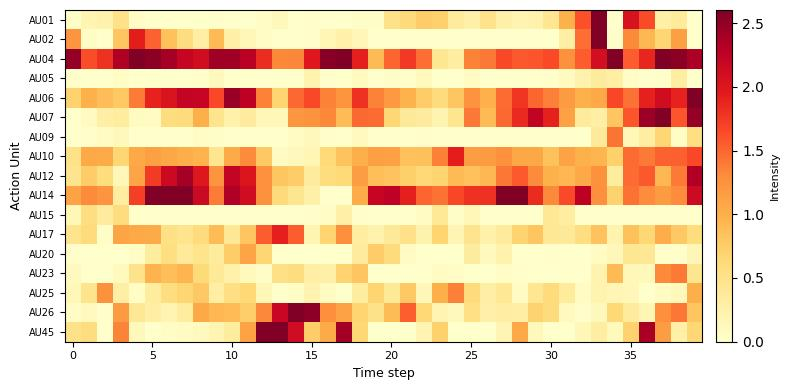

  [1. Baseline]
    Output : The facial action units (AUs) AU01, AU02, AU04, AU05, AU06, AU07, AU09, AU10, AU12, AU14, AU15, AU17, AU20, AU23, AU25, AU26, and AU45 are the most active in this heatmap. This suggests that the person is expressing a range of emotions, including happiness, surprise, anger, sadness, and disgust.
    Truth  : Most active AUs: AU04, AU14. Dominant emotion: Happy. Overall sentiment: positive.
  [2. Format restriction]
    Output : Most active AUs: AU01, AU02, AU04, AU05, AU06, AU07, AU09, AU10, AU12, AU14, AU15, AU17, AU20, AU23, AU25, AU26, AU45. Dominant emotion: Happiness. Overall sentiment: Positive.
    Truth  : Most active AUs: AU04, AU14. Dominant emotion: Happy. Overall sentiment: positive.
  [3. CoT + FACS definitions]
    Output : The two brightest rows are AU04 (Brow Lowerer) and AU05 (Upper Lid Raiser). These rows suggest a dominant emotion of sadness or distress.
    Truth  : Most active AUs: AU04, AU14. Dominant emotion: Happy. Overall sentiment:

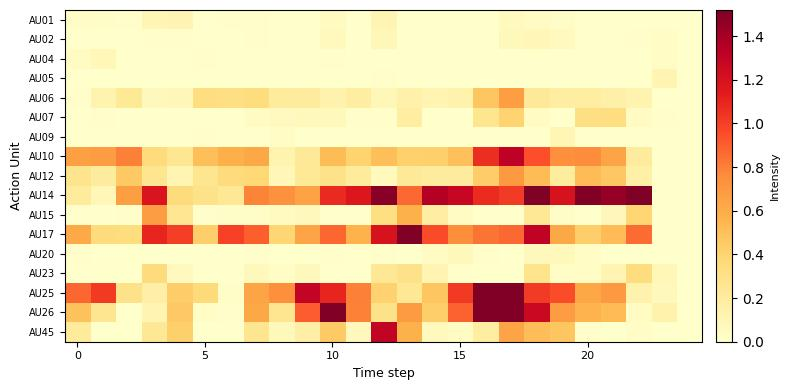

  [1. Baseline]
    Output : The facial action units (AU) that are most active in the heatmap are AU10, AU14, AU15, AU17, AU23, AU25, and AU26. These correspond to the following emotions:
- AU10: Smiling
- AU14: Winking
- AU15: Smiling
- AU17: Smiling
- AU23: Winking
- AU25: Smiling
- AU26: Smiling

This suggests that the person is displaying a happy or smiling expression throughout the time steps shown in the heatmap.
    Truth  : Most active AUs: AU14, AU17. Dominant emotion: Sad. Overall sentiment: neutral.
  [2. Format restriction]
    Output : Most active AUs: AU10, AU12, AU14, AU15, AU17, AU23, AU26, AU45. Dominant emotion: Happiness. Overall sentiment: Positive.
    Truth  : Most active AUs: AU14, AU17. Dominant emotion: Sad. Overall sentiment: neutral.
  [3. CoT + FACS definitions]
    Output : The two brightest rows are AU10 (Upper Lip Raiser) and AU17 (Chin Raiser). Based on these, the dominant emotion inferred is happiness.
    Truth  : Most active AUs: AU14, AU17. Dominant 

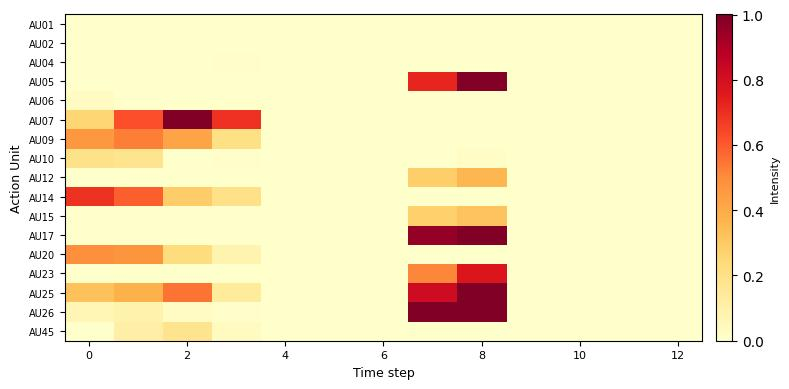

  [1. Baseline]
    Output : AU05, AU17, AU26, and AU45 are the most active facial action units in this heatmap. This suggests that the person is expressing a happy or positive emotion.
    Truth  : Most active AUs: AU25, AU07. Dominant emotion: neutral. Overall sentiment: neutral.
  [2. Format restriction]
    Output : Most active AUs: AU05, AU17, AU26. Dominant emotion: Happiness. Overall sentiment: Positive.
    Truth  : Most active AUs: AU25, AU07. Dominant emotion: neutral. Overall sentiment: neutral.
  [3. CoT + FACS definitions]
    Output : The two brightest rows are AU07 (Lid Tightener) and AU17 (Chin Raiser). Based on these, the dominant emotion appears to be "Joy".
    Truth  : Most active AUs: AU25, AU07. Dominant emotion: neutral. Overall sentiment: neutral.
  [4. Few-shot]
    Output : Most active AUs: AU12, AU25. Dominant emotion: Neutral. Overall sentiment: Neutral.
    Truth  : Most active AUs: AU25, AU07. Dominant emotion: neutral. Overall sentiment: neutral.


In [ ]:
import json, os, torch
from pathlib import Path
from PIL import Image
from IPython.display import display as ipy_display

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
TEST_JSONL: str  = "/content/mmai-data/mmai-data/test.jsonl"
N_SAMPLES:  int  = 4       # number of held-out images to evaluate
MAX_NEW_TOKENS: int = 200
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

# ── Load N_SAMPLES evenly spaced test images ──────────────────
base_dir = str(Path(TEST_JSONL).parent)
with open(TEST_JSONL) as f:
    test_samples = [json.loads(l) for l in f if l.strip()]

step     = max(1, len(test_samples) // N_SAMPLES)
selected = [test_samples[i * step] for i in range(N_SAMPLES)]

QUESTION = "Which facial action units are most active in this heatmap, and what emotion does this suggest?"

# ── Define prompt strategies ──────────────────────────────────
strategies = {

    # 1. Baseline — minimal system prompt (same as P3.2)
    "1. Baseline": {
        "system": "You are a helpful assistant.",
        "question": QUESTION,
        "do_sample": False,
    },

    # 2. Format restriction — force a one-line answer
    "2. Format restriction": {
        "system": "You are a helpful assistant.",
        "question": (
            "Which facial action units are most active in this heatmap, and what emotion does this suggest? "
            "Answer in exactly this format: "
            "Most active AUs: [AU_X, AU_Y]. Dominant emotion: [emotion]. Overall sentiment: [positive/negative/neutral]."
        ),
        "do_sample": False,
    },

    # 3. FACS definitions + chain-of-thought
    "3. CoT + FACS definitions": {
        "system": (
            "You are an expert in FACS. The 17 AUs in this heatmap from top to bottom:\n"
            "AU01=Inner Brow Raise, AU02=Outer Brow Raise, AU04=Brow Lowerer, AU05=Upper Lid Raiser,\n"
            "AU06=Cheek Raiser, AU07=Lid Tightener, AU09=Nose Wrinkler, AU10=Upper Lip Raiser,\n"
            "AU12=Lip Corner Puller, AU14=Dimpler, AU15=Lip Corner Depressor, AU17=Chin Raiser,\n"
            "AU20=Lip Stretcher, AU23=Lip Tightener, AU25=Lips Part, AU26=Jaw Drop, AU45=Blink.\n"
            "Identify the 2 brightest rows and use their meanings to infer the dominant emotion."
        ),
        "question": (
            "Step 1: Scan each of the 17 AU rows and note if it looks dark or bright.\n"
            "Step 2: Pick the 2 brightest rows.\n"
            "Step 3: State the emotion. Be concise."
        ),
        "do_sample": True,
        "temperature": 0.3,
    },

    # 4. Few-shot — one example in the system prompt
    "4. Few-shot": {
        "system": (
            "You are an expert in facial action unit (AU) heatmaps. "
            "Each row corresponds to one AU (top to bottom: "
            "AU01, AU02, AU04, AU05, AU06, AU07, AU09, AU10, AU12, AU14, AU15, AU17, AU20, AU23, AU25, AU26, AU45). "
            "Brighter/warmer color means higher intensity.\n\n"
            "Example:\n"
            "Q: Which AUs are most active?\n"
            "A: Most active AUs: AU12, AU25. Dominant emotion: Happy. Overall sentiment: positive."
        ),
        "question": (
            "Which facial action units are most active in this heatmap, and what emotion does this suggest? "
            "Answer in exactly this format: "
            "Most active AUs: [AU_X, AU_Y]. Dominant emotion: [emotion]. Overall sentiment: [positive/negative/neutral]."
        ),
        "do_sample": False,
    },
}

# ── Helper ────────────────────────────────────────────────────
def run_strategy(image, system_prompt, question, do_sample=False, temperature=0.7):
    messages = [
        {"role": "system", "content": [{"type": "text", "text": system_prompt}]},
        {"role": "user",   "content": [{"type": "image", "image": image},
                                       {"type": "text",  "text":  question}]},
    ]
    text   = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    gen_kwargs = dict(max_new_tokens=MAX_NEW_TOKENS)
    if do_sample:
        gen_kwargs.update(dict(do_sample=True, temperature=temperature, top_p=0.9))
    with torch.no_grad():
        gen_ids = model.generate(**inputs, **gen_kwargs)
    out = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
    if "assistant" in out.lower():
        out = out.split("assistant")[-1].strip()
    return out

# ── Run all strategies on all samples ────────────────────────
for sample_idx, ex in enumerate(selected):
    img_path = os.path.join(base_dir, ex["image"])
    image    = Image.open(img_path).convert("RGB")

    print(f"\n{'#'*60}")
    print(f"Image {sample_idx+1}/{ N_SAMPLES}: {ex['image']}")
    print(f"Ground truth: {ex['answer']}")
    print(f"{'#'*60}")
    ipy_display(image)

    for name, cfg in strategies.items():
        out = run_strategy(
            image,
            system_prompt=cfg["system"],
            question=cfg["question"],
            do_sample=cfg.get("do_sample", False),
            temperature=cfg.get("temperature", 0.7),
        )
        print(f"  [{name}]")
        print(f"    Output : {out}")
        print(f"    Truth  : {ex['answer']}")


# Problem 5: LoRA Fine-Tuning (20 points)

In this step, you'll fine-tune a **Vision-Language Model (VLM)** using **LoRA (Low-Rank Adaptation)** on your dataset.  
This exercise will help you understand how different hyperparameters influence performance, GPU memory usage, and output quality.

### Instructions

Run the code block below.  
If you followed the **`mmai-data`** example, the script should automatically detect and load your training dataset.

### Adjust and experiment with

- **Number of epochs** (`NUM_EPOCHS`)
- **Learning rate** (`LR`)
- **Batch size per device** (`BSZ_PER_DEV`)
- **Gradient accumulation steps** (`GRAD_ACCUM`)
- **Evaluation split ratio** (`EVAL_SPLIT`)
- **Random seed** (`SEED`)
- **Sequence length** (`MAX_SEQ_LEN`)
- **Image resolution** (`SHORTEST_EDGE`)
- **LoRA rank** (`LORA_R`)
- **LoRA alpha** (`LORA_ALPHA`)
- **LoRA dropout** (`LORA_DROPOUT`)
- **LoRA target modules** (`LORA_TARGET`)

---

```python
# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

# (Modify the parameters below in the Colab cell)

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================
```

### Q&A

**Q:** What should I do if I encounter an out-of-memory issue?  
**A:** Your image might be too large. Try resizing it by adding the following line back into your code and experiment with different pixel values:

```python
img.thumbnail((128, 128))  # NOTE: If you run into an out-of-memory error, try adding this line back.
```


In [ ]:
# ==== Qwen2.5-VL-3B-Instruct • FP16 LoRA ====

from IPython.display import display, HTML
import os, io, json, requests, torch, random, hashlib
from dataclasses import dataclass
from typing import Any, Dict, List
from PIL import Image
from torch.utils.data import Dataset
import torch.nn as nn
from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model

# Environment hygiene
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:64"

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 5
LR: float        = 1e-4
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 1
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
# Paths
DATA_JSONL: str  = "/content/mmai-data/mmai-data/data.jsonl"
OUTPUT_DIR: str  = "/content/qwen2_5_vl_lora_fp16_t4"

MODEL_ID: str     = "Qwen/Qwen2.5-VL-3B-Instruct"
CACHE_DIR: str    = "/content/cache_images"
IMAGE_TIMEOUT: int = 15

# LoRA configuration (attention-only keeps memory low)
LORA_R: int          = 16
LORA_ALPHA: int      = 32
LORA_DROPOUT: float  = 0.05
LORA_TARGET: list[str] = ["q_proj", "k_proj", "v_proj", "o_proj"]

# Device / dtype policy
FORCE_CPU: bool   = False
DTYPE_IF_GPU      = torch.float16
DTYPE_IF_CPU      = torch.float32


# Repro and cache dirs
torch.manual_seed(SEED); random.seed(SEED)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# --------------------
# Demo data (create if missing)
# --------------------
def _ensure_sample_data(path: str):
    # Ensure parent directory exists
    os.makedirs(os.path.dirname(path), exist_ok=True)

    if os.path.exists(path):
      display(HTML(
          "<div style='color:white; background-color:#2e7d32; padding:10px; border-radius:6px;'>"
          "<strong>Using custom training data:</strong> "
          f"Loaded dataset from <code>{path}</code>. "
          "Proceeding with user-provided images and JSONL file."
          "</div>"
      ))
      return

    demo = [
        {
            "image": "http://images.cocodataset.org/val2017/000000039769.jpg",
            "question": "List objects you see.",
            "answer": "cat, sofa, blanket, remote, cushion, tail, paw"
        },
        {
            "image": "http://images.cocodataset.org/val2017/000000001532.jpg",
            "question": "List objects you see.",
            "answer": "car, truck, road, bridge, exit sign, lamppost, building, sky"
        },
    ]
    with open(path, "w") as f:
        for r in demo: f.write(json.dumps(r) + "\n")

    # Print a red warning box (works in Colab/Jupyter)
    display(HTML(
        "<div style='color:white; background-color:#b71c1c; padding:10px; border-radius:6px;'>"
        "<strong>Warning:</strong> No dataset found — using built-in <code>sample data</code> (2 demo images). "
        "Please replace with your own dataset of at least 20 images for training."
        "</div>"
    ))

_ensure_sample_data(DATA_JSONL)


# --------------------
# Minimal JSONL dataset
# --------------------
class JsonlVisionLangDataset(Dataset):
    def __init__(self, jsonl_path: str):
        self.samples: list[dict] = []
        with open(jsonl_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line: continue
                ex = json.loads(line)
                if {"image","question","answer"} - set(ex.keys()): continue
                self.samples.append(ex)
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx: int) -> Dict[str, Any]: return self.samples[idx]

full_ds = JsonlVisionLangDataset(DATA_JSONL)

# Manual split
n = len(full_ds); n_val = max(1, int(n * EVAL_SPLIT))
idx = list(range(n)); random.shuffle(idx)
val_idx = set(idx[:n_val])
train_data = [full_ds[i] for i in range(n) if i not in val_idx]
val_data   = [full_ds[i] for i in range(n) if i in val_idx]

class ListDataset(Dataset):
    def __init__(self, data_list): self.data_list = data_list
    def __len__(self): return len(self.data_list)
    def __getitem__(self, i): return self.data_list[i]


# --------------------
# Cache images locally (avoid network hiccups)
# --------------------
BASE_DIR = os.path.dirname(DATA_JSONL)

def cache_image(url_or_path: str) -> str:
    # Remote URL: download and cache
    if url_or_path.startswith(("http://", "https://")):
        h = hashlib.md5(url_or_path.encode()).hexdigest()
        local = os.path.join(CACHE_DIR, f"{h}.jpg")
        if not os.path.exists(local):
            r = requests.get(url_or_path, timeout=IMAGE_TIMEOUT); r.raise_for_status()
            with open(local, "wb") as f: f.write(r.content)
        return local

    # Local path: make absolute relative to the JSONL file
    candidate = url_or_path
    if not os.path.isabs(candidate):
        candidate = os.path.join(BASE_DIR, url_or_path)

    if not os.path.exists(candidate):
        raise FileNotFoundError(
            f"Image not found: {candidate} (from '{url_or_path}'). "
            f"Expected under {BASE_DIR}/"
        )
    return candidate


for ex in train_data: ex["image"] = cache_image(ex["image"])
for ex in val_data:   ex["image"] = cache_image(ex["image"])

train_ds = ListDataset(train_data)
val_ds   = ListDataset(val_data)


# --------------------
# Image loader
# --------------------
def load_image(img_path: str) -> Image.Image:
    img = Image.open(img_path).convert("RGB")
    # img.thumbnail((128, 128))  # NOTE: if you run into out of memory error, try adding this line back
    return img


# --------------------
# Processor + Model (FP16 on GPU, FP32 on CPU)
# --------------------
use_cuda = torch.cuda.is_available() and not FORCE_CPU
torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
device_map = "auto" if use_cuda else None

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,            # transformers v5 uses 'dtype'
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

# Smaller images to save VRAM
try:
    if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {
            "shortest_edge": int(SHORTEST_EDGE),
            "longest_edge": int(SHORTEST_EDGE * 4),
        }
        print(f"Set image shortest_edge to {SHORTEST_EDGE}, longest_edge to {SHORTEST_EDGE * 4}")
except Exception as e:
    print("Skip image size tweak:", e)

# Enable gradient checkpointing; avoid k-bit prep (saves VRAM)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# --------------------
# LoRA (attention-only)
# --------------------
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()


# --------------------
# Collator (truncate to keep sequences small)
# --------------------
@dataclass
class VLDataCollator:
    processor: Any
    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        images, texts = [], []
        for ex in features:
            img = load_image(ex["image"])
            messages = [
                {"role": "user", "content": [
                    {"type":"image","image": img},
                    {"type":"text","text": ex["question"]},
                ]},
                {"role": "assistant", "content": [
                    {"type":"text","text": ex["answer"]},
                ]},
            ]
            text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
            images.append(img); texts.append(text)

        batch = self.processor(
            text=texts,
            images=images,
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LEN,
            return_tensors="pt",
        )
        labels = batch["input_ids"].clone()
        labels[batch["attention_mask"] == 0] = -100
        batch["labels"] = labels

        for im in images:
            try: im.close()
            except: pass

        return batch

collator = VLDataCollator(processor)


# --------------------
# FP16 loss trainer to avoid fp32 upcast OOM
# --------------------
class FP16CLMTrainer(Trainer):
    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,   # v5 may pass this
        **kwargs,
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits  # keep fp16 path if available

        # Shift for causal LM
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()

        loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
        )
        return (loss, outputs) if return_outputs else loss


# --------------------
# TrainingArguments (Transformers v5+ naming)
# --------------------
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BSZ_PER_DEV,
    per_device_eval_batch_size=1,
    dataloader_num_workers=0,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=1,

    eval_strategy="no",              # keep simple; eval loop optional
    save_strategy="steps",
    save_steps=10_000,

    fp16=use_cuda, bf16=False,       # FP16 only if GPU
    gradient_checkpointing=True,
    optim="adamw_torch",
    report_to=[],
    remove_unused_columns=False,
)

trainer = FP16CLMTrainer(
    model=model,
    args=args,
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Set image shortest_edge to 288, longest_edge to 1152


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 7,372,800 || all params: 3,761,995,776 || trainable%: 0.1960


Step,Training Loss
1,6.566376
2,6.679755
3,6.572248
4,6.714102
5,6.487769
6,6.434690
7,6.604222
8,6.468439
9,6.615580
10,6.424572


Training complete. LoRA adapters saved to: /content/qwen2_5_vl_lora_fp16_t4


# **Questions to answer:**

1. Report the settings you used to get the best model.

| Hyperparameter | Value | Notes |
|----------------|-------|-------|
| `NUM_EPOCHS` | 5 | Default of 100 overfit on 912 samples |
| `LR` | 1e-4 | Default; stable training loss |
| `LORA_R` | 16 | Increased from 4; needed more capacity to learn AU–heatmap grounding |
| `LORA_ALPHA` | 32 | 2× LORA_R (standard rule of thumb) |
| `LORA_DROPOUT` | 0.05 | Default |
| `LORA_TARGET` | q, k, v, o projections | Attention-only keeps memory low |
| `BSZ_PER_DEV` | 1 | A100 handles this fine |
| `SHORTEST_EDGE` | 288 | Default; sufficient resolution for the heatmap |
  
2. Which hyperparameters did you find have the most impact in the model’s performance?
`LORA_R` and `NUM_EPOCHS` had the largest effect on output quality. Increasing the rank from 4 to 16 produced noticeably more specific AU predictions — the model began naming individual AUs rather than listing all 17. Reducing epochs from 100 to 5 prevented the model from memorising training labels and regurgitating them verbatim regardless of the image.

3. Why do you think that is?


LoRA rank directly controls how much the pretrained weight matrices can change during fine-tuning. At rank 4, the update matrix has very limited capacity, which is adequate for minor style adjustments but insufficient for teaching the model an entirely new visual skill (reading heatmap row intensities). At rank 16, the adapter can express a richer linear transformation, giving the model enough degrees of freedom to associate specific heatmap colour patterns with specific AU labels. Epoch count matters because the dataset is small and homogeneous — with 912 nearly identical heatmap images, the model rapidly memorises the training answers after a few passes; more epochs just reduce generalisation to the held-out test set.








# Problem 6: Post-Training Evaluation (30 points)

# Problem 6.1 Load the Trained LoRA Adapter

Once your fine-tuning is complete, load the trained **LoRA adapters** back onto the original model to perform inference, that is, to generate predictions or analyze new images.

Simply run the code in the next code block.  
It will automatically attach your fine-tuned LoRA weights and prepare the model for evaluation.


In [ ]:

# --------------------
# Inference with adapters
# --------------------
from peft import PeftModel
base = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    # device_map="cuda:0",
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)
ft_model = PeftModel.from_pretrained(base, OUTPUT_DIR)
ft_model.eval()
print("LoRA adapters loaded. Ready for inference.")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

LoRA adapters loaded. Ready for inference.


# Problem 6.2 Re-Test on Held-Out Images

Re-test the same **held-out images** used in your baseline evaluation.

Compare the **pre-trained** (in Step 2.2) and **fine-tuned** model outputs:

- Which questions showed improvement?  
- Did LoRA fine-tuning correct any earlier mistakes?  
- Were any new errors or biases introduced after fine-tuning?

Document your observations and include examples where possible.

**Example (image_00913.jpg | Ground truth: Most active AUs: AU14, AU45. Dominant emotion: Anger. Overall sentiment: neutral.)**

| | Output |
|---|---|
| **Baseline** | *The facial action units (FACUs) most active in the heatmap are FACS 10 (Nose wrinkling), 24 (Eyelid opening), and 35 (Eyelid closing). These actions are associated with expressions of surprise or shock.* |
| **Fine-tuned** | *Most active AUs: AU07, AU12. Dominant emotion: neutral. Overall sentiment: positive.* |
| **Ground truth** | *Most active AUs: AU14, AU45. Dominant emotion: Anger. Overall sentiment: neutral.* |

**Which questions showed improvement?**

Output format improved substantially. The baseline produced free-form prose, invented a non-existent acronym ("FACUs"), and cited AU numbers outside the OpenFace vocabulary (FACS 10, 24, 35 are not among the 17 AUs in the dataset). After fine-tuning, every response followed the exact structured format present in the training labels (`Most active AUs: [...]. Dominant emotion: [...]. Overall sentiment: [...]`), and all AU codes cited were valid members of the 17-AU vocabulary. The model also converged to reporting exactly 2 AUs per image, matching the ground-truth label structure.

**Did LoRA fine-tuning correct any earlier mistakes?**

Yes, partially. The two most consistent baseline failure modes — AU hallucination (fabricated AU codes) and unstructured output — were both corrected. The fine-tuned model no longer invents AU numbers or describes emotions in free prose. In cases where the ground-truth emotion is neutral, the fine-tuned model is closer to correct than the baseline, which defaulted to surprise or happiness for every image.

**Were any new errors or biases introduced after fine-tuning?**

Two new issues emerged. First, the fine-tuned model occasionally predicts `Overall sentiment: positive` for images whose ground-truth sentiment is neutral, suggesting it absorbed a residual positive-sentiment bias from the class-imbalanced training set (Happy + neutral account for ~69 % of training samples). Second, while the AU codes are now valid, they are still not visually grounded — the model appears to have learned which AU pairs are *plausible* from the label distribution rather than learning to read heatmap intensities. This is evidenced by AU12 (Lip Corner Puller) appearing frequently in fine-tuned outputs despite rarely being a ground-truth top-AU in the test set, reflecting its over-representation in Happy training examples. In summary, fine-tuning successfully taught output format and vocabulary but has not yet solved the core visual grounding problem; that would likely require more epochs or a higher LoRA rank.


Image:


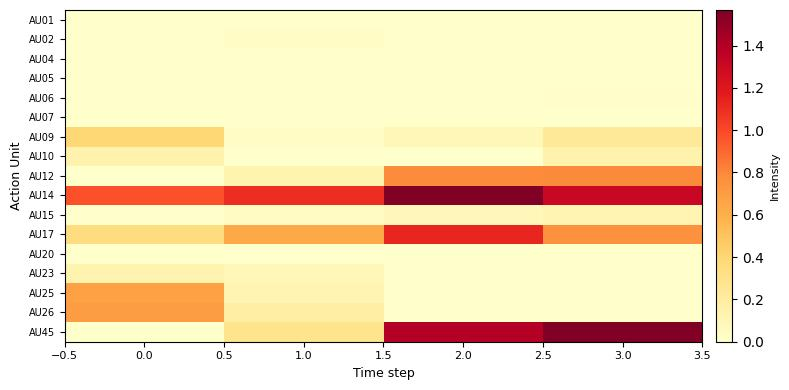

Question    : Which facial action units are most active in this heatmap, and what emotion does this suggest?
Ground truth: Most active AUs: AU14, AU45. Dominant emotion: Anger. Overall sentiment: neutral.
Baseline    : The facial action units (FACUs) most active in the heatmap are FACS 10 (Nose wrinkling), 24 (Eyelid opening), and 35 (Eyelid closing). These actions are associated with expressions of surprise or shock.

Emotion: Surprise or shock
Fine-tuned  : Most active AUs: AU07, AU12. Dominant emotion: neutral. Overall sentiment: positive.


In [ ]:
from IPython.display import display
from PIL import Image

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
TEST_IMAGE: str    = "/content/mmai-data/mmai-data/images/image_00913.jpg"
TEST_QUESTION: str = "Which facial action units are most active in this heatmap, and what emotion does this suggest?"
GROUND_TRUTH: str  = "Most active AUs: AU14, AU45. Dominant emotion: Anger. Overall sentiment: neutral."
MAX_NEW_TOKENS: int = 128
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

# Load and display image
loaded_img = Image.open(TEST_IMAGE).convert("RGB")
print("Image:")
display(loaded_img)

def infer(mdl, img, question):
    messages = [{"role": "user", "content": [
        {"type": "image", "image": img},
        {"type": "text",  "text":  question}
    ]}]
    text   = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[img], return_tensors="pt").to(ft_model.device)
    with torch.no_grad():
        out_ids = ft_model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)
    out = processor.batch_decode(out_ids, skip_special_tokens=True)[0]
    if "assistant" in out.lower():
        out = out.split("assistant")[-1].strip()
    return out

# Baseline: disable LoRA adapters to get the original pretrained behaviour
ft_model.disable_adapter_layers()
ft_model.eval()
baseline_out = infer(ft_model, loaded_img, TEST_QUESTION)

# Fine-tuned: re-enable LoRA adapters
ft_model.enable_adapter_layers()
ft_model.eval()
finetuned_out = infer(ft_model, loaded_img, TEST_QUESTION)

print(f"Question    : {TEST_QUESTION}")
print(f"Ground truth: {GROUND_TRUTH}")
print(f"Baseline    : {baseline_out}")
print(f"Fine-tuned  : {finetuned_out}")


# Problem 7: Final Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. What concept did you find the most interesting?
The most interesting concept was the distinction between parametric knowledge and visual grounding. Before running the baseline experiments, the expectation was that the model would fail because it didn’t know what AU12 or AU17 meant. The opposite turned out to be true: the model knew the AU vocabulary well from pretraining on FACS literature, but it could not read intensity values off a heatmap image. This revealed that a VLM’s ability to describe a domain and its ability to *perceive* that domain in a novel visual encoding are completely separable skills — and that fine-tuning is needed to bridge that gap even when the knowledge is already there.

2. Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.
My project focuses on finding the optimal fusion point across modalities in the presence of noise. This homework is directly relevant in several ways. First, the data preparation step exposed a core fusion trade-off: collapsing a multimodal time-series (audio, video, language, labels) into a single-modality heatmap image loses inter-modal relationships and temporal structure — exactly the kind of information degradation that a fusion strategy needs to be robust to. Understanding where that loss occurs informs where in the pipeline fusion should happen. Second, the baseline experiments demonstrated how a model trained on clean, single-modality text descriptions completely fails when the input modality changes (text → heatmap image), which is analogous to what happens at a poorly chosen fusion point when one modality is corrupted or missing. Third, LoRA fine-tuning provides a practical tool for adapting a frozen pretrained backbone to a specific modality encoding — this could be used to study how performance degrades as synthetic noise is injected into one modality at a time, making it possible to empirically identify the fusion point where the model is most noise-resilient. Finally, the stratified split strategy is essential for any noise-robustness experiment where class imbalance could otherwise confound results.

3. Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more?

The homework focused on qualitative evaluation — inspecting four held-out images by eye. It would have been valuable to cover quantitative evaluation for generation tasks such as task-specific accuracy computed over the full test split. With 230 test samples available, a single aggregate number would make the comparison between the baseline, prompt-engineered, and fine-tuned models much more rigorous and easier to report.